# Figure 1I — knockout enrichment across cell states

Tests whether each gene knockout is over- or under-represented in the four
dendritic-cell states, and draws the odds-ratio heatmap that is Figure 1I.

Cells are pooled from the single- and multiple-knockout objects. For every
knockout, a Fisher test compares its cell counts in one state against the
population as a whole, in both directions; p-values are FDR corrected and the
significant odds ratios become the heatmap.

## Setup

In [1]:
from pathlib import Path

import pandas as pd
import scanpy as sc

%load_ext rpy2.ipython

sc.set_figure_params(dpi=100, fontsize=12)
sc.settings.verbosity = "hint"

In [2]:
E3LIGASE = Path("/home/eraslab1/Projects/E3Ligase/analysisSingle")
ORIGINAL = E3LIGASE / "outputs/anndata/OriginalFiles"

MULTIPLE_KO_H5AD = ORIGINAL / "adata-hash-features_singlets_MultipleKO_06292020_PerGENE.h5ad"
SINGLE_KO_H5AD   = ORIGINAL / "adata-hash-features_singlets_SingleKO_06292020_PerGENE.h5ad"

OUTPUT_DIR = Path("outputs"); OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR = Path("figures"); FIGURE_DIR.mkdir(exist_ok=True)

# leiden cluster -> cell state; every other cluster is DC2
SUBCELL_TYPE_BY_CLUSTER = {"3": "MacDC", "8": "DC1", "5": "MReg"}
CELL_STATES = ["DC1", "DC2", "MReg", "MacDC"]

# guide columns that are not gene knockouts
EXCLUDED_GUIDES = ["GENE_CONTROL_", "GENE_INEFFECT_"]

## Load and pool the knockout cells

The guide list comes from the multiple-knockout object, which carries the
complete set; the counts are taken from both objects combined.

In [3]:
adata1 = sc.read(MULTIPLE_KO_H5AD)     # multiple knockouts, and the guide list
adata2 = sc.read(SINGLE_KO_H5AD)       # single knockouts
adata = sc.concat([adata1, adata2])

adata.obs["subCellType"] = "DC2"
for cluster, label in SUBCELL_TYPE_BY_CLUSTER.items():
    adata.obs.loc[adata.obs.leiden.isin([cluster]), "subCellType"] = label

adata.obs["subCellType"].value_counts()

DC2      265763
MacDC     45655
MReg       8562
DC1        3943
Name: subCellType, dtype: int64

## Count cells per knockout and cell state

In [4]:
covariates = adata1.uns["feature_barcode_names_filtered_GENES"]
covariates = [g for g in covariates if g not in EXCLUDED_GUIDES]

# one binary column per knockout: did this cell receive that guide
fBarMat = adata.obs[covariates].copy()
fBarMat[fBarMat > 0] = 1
fBarMat["subCellType"] = adata.obs["subCellType"]

allGuidesPerSCT = pd.concat(
    [
        pd.crosstab(fBarMat[guide], fBarMat.subCellType)
        .loc[lambda df: df.index == 1]
        .assign(KOGuide=guide)
        for guide in covariates
    ]
)
allGuidesPerSCT["noOfGuideCells"] = allGuidesPerSCT[CELL_STATES].sum(axis=1)

print(f"{len(allGuidesPerSCT)} knockouts")
print(allGuidesPerSCT[CELL_STATES].sum(axis=0))
allGuidesPerSCT.head()

1031 knockouts
subCellType
DC1        3814
DC2      308005
MReg       8670
MacDC     50396
dtype: int64


subCellType,DC1,DC2,MReg,MacDC,KOGuide,noOfGuideCells
1,2,447,12,64,GENE_4921501E09Rik_,525
1,10,645,13,90,GENE_4930595M18Rik_,758
1,2,119,1,24,GENE_8030462N17Rik_,146
1,1,154,9,1,GENE_Aamp_,165
1,2,296,6,50,GENE_Abtb1_,354


## Enrichment of each knockout in each cell state

For every knockout and state, a 2×2 table of that knockout's cells in the state
against the whole population is tested with Fisher's exact test in both
directions, then FDR corrected. Knockouts with no cells left are skipped.

In [5]:
%%R -i allGuidesPerSCT

CELL_STATES <- c("DC1", "DC2", "MReg", "MacDC")

allGuidesPerSCT$KOGuide <- as.character(allGuidesPerSCT$KOGuide)
rownames(allGuidesPerSCT) <- allGuidesPerSCT$KOGuide

for (state in CELL_STATES) {
    allGuidesPerSCT[paste0(state, "_pval_greater")]     <- -1
    allGuidesPerSCT[paste0(state, "_estimate_greater")] <- -1
    allGuidesPerSCT[paste0(state, "_pval_less")]        <- -1
    allGuidesPerSCT[paste0(state, "_estimate_less")]    <- -1
}

totalCountsPerSCT <- data.frame(
    subCelltype = CELL_STATES,
    cellCounts  = colSums(allGuidesPerSCT[, CELL_STATES])
)
rownames(totalCountsPerSCT) <- totalCountsPerSCT$subCelltype
totalNoOfCells <- sum(totalCountsPerSCT$cellCounts)

for (guide in as.character(unique(allGuidesPerSCT$KOGuide))) {
    if (allGuidesPerSCT[guide, "noOfGuideCells"] == 0) next   # nothing to test

    for (state in CELL_STATES) {
        contingency <- data.frame(
            clusterNo = c(
                allGuidesPerSCT[guide, state],
                allGuidesPerSCT[guide, "noOfGuideCells"] - allGuidesPerSCT[guide, state]
            ),
            restNo = c(
                totalCountsPerSCT[state, "cellCounts"],
                totalNoOfCells - totalCountsPerSCT[state, "cellCounts"]
            )
        )

        for (direction in c("greater", "less")) {
            testRes <- fisher.test(x = contingency, alternative = direction)
            allGuidesPerSCT[guide, paste0(state, "_pval_", direction)]     <- testRes$p.value
            allGuidesPerSCT[guide, paste0(state, "_estimate_", direction)] <- testRes$estimate
        }
    }
}

for (state in CELL_STATES) {
    for (direction in c("greater", "less")) {
        allGuidesPerSCT[, paste0(state, "_FDR_", direction)] <-
            p.adjust(allGuidesPerSCT[, paste0(state, "_pval_", direction)])
    }
}

## Assemble the odds-ratio matrix

Only tests passing the FDR threshold contribute; everything else stays at an
odds ratio of 1. Ratios are capped so a few extreme values do not flatten the
colour scale, and knockouts are ordered by their DC2 enrichment.

In [6]:
%%R

library(reshape2)

FDR_THRESHOLD  <- 0.15
ODDS_RATIO_CAP <- 2

fdrColumns <- c(paste0(CELL_STATES, "_FDR_greater"), paste0(CELL_STATES, "_FDR_less"))
significant <- melt(allGuidesPerSCT[, c(fdrColumns, "KOGuide")], id.vars = "KOGuide")
significant <- significant[significant$value < FDR_THRESHOLD, ]

significant$celltype <- sapply(significant$variable, function(x) strsplit(as.character(x), "_")[[1]][1])
significant$testType <- sapply(significant$variable, function(x) strsplit(as.character(x), "_")[[1]][3])

# the odds ratio behind each significant test
significant$oddRatio <- mapply(
    function(guide, state, direction) allGuidesPerSCT[guide, paste0(state, "_estimate_", direction)],
    significant$KOGuide, significant$celltype, significant$testType
)

kk <- data.frame(matrix(1.0, nrow = length(CELL_STATES),
                        ncol = length(unique(significant$KOGuide))))
colnames(kk) <- unique(significant$KOGuide)
rownames(kk) <- CELL_STATES
for (i in seq_len(nrow(significant))) {
    kk[significant[i, "celltype"], significant[i, "KOGuide"]] <- significant[i, "oddRatio"]
}

kk[kk > ODDS_RATIO_CAP] <- ODDS_RATIO_CAP
kk <- data.frame(t(kk[c("DC2", "MacDC", "MReg", "DC1"), ]))
kk <- kk[order(-kk$DC2, kk$MacDC, kk$MReg, -kk$DC1), ]
rownames(kk) <- sapply(rownames(kk), function(x) strsplit(x, "_")[[1]][2])

dim(kk)

[1] 64  4


## Figure 1I

png 
  2 


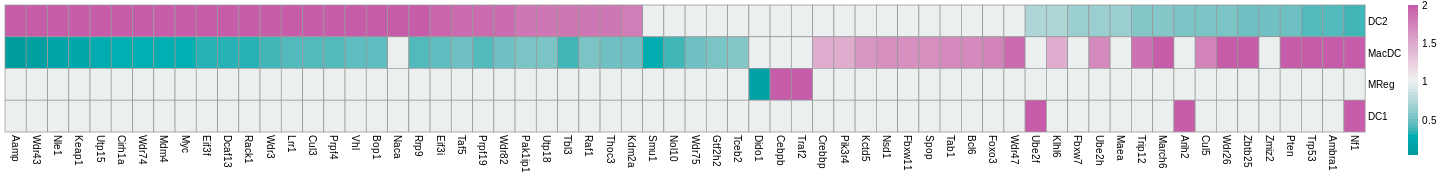

In [7]:
%%R -w 20 -h 2.5 -u in

library(pheatmap)

save_pheatmap_pdf <- function(x, filename, width = 7, height = 7) {
    stopifnot(!missing(x), !missing(filename))
    pdf(filename, width = width, height = height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

heatmap1I <- pheatmap(
    t(kk), cluster_rows = FALSE, cluster_cols = FALSE,
    treeheight_col = 0, treeheight_row = 0,
    color = hcl.colors(50, "Tropic"), clustering_method = "ward.D2"
)

write.csv(t(kk), "outputs/Fig_1I.csv")
save_pheatmap_pdf(heatmap1I, "figures/Figure_1I.pdf", width = 20, height = 2)